In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
# Data from observations
bins        = 0

region     = 'M 42'
name_reg   = 'Orion'
reg_id     = 'M42'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'

pix        = 0.2   # Instrument resolution [arcsec/pix]
dist       = 410 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

In [3]:
hdul_mask = fits.open('mask.fits')
hdr_mask = hdul_mask[0].header
mask = hdul_mask['MASK'].data.astype(bool)

In [4]:
from rebin_utils import downsample

In [5]:
from pipeline_config import OBSERVATIONS_DIR
from spectral_lines import LINES, print_available_lines

In [6]:
print_available_lines()

Halpha
NII_6583
SII_6731
OIII_5007
ArIII_7136
SIII_9069


In [7]:
cfg = LINES["Halpha"]

plot_label = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
element = cfg.element
ion = cfg.ion
transition_id = cfg.transition_id

In [8]:
name_file    =  transition_id
name_id      =  inst_id + '-' + reg_id + '-' + element 
print(name_file)
print(name_id)

H_I-6563
MUSE-M42-H


In [9]:

flux_path    = OBSERVATIONS_DIR / f'linesum-{name_file}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name_file}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

sb = flux[0].data.astype(float)
vv = rad_vel[0].data.astype(float)
#ss    = np.array(_data['ss'])

In [10]:
selected_lines = ["Halpha", "NII_6583", "SII_6731","OIII_5007",'ArIII_7136',"SIII_9069"]

line_data = {}

for line_key in selected_lines:

    cfg = LINES[line_key]

    name_file = cfg.transition_id
    name_id = f"{inst_id}-{reg_id}-{cfg.element}"

    flux_path = OBSERVATIONS_DIR / f"linesum-{name_file}.fits"
    radvel_path = OBSERVATIONS_DIR / f"mean-{name_file}-patfixx.fits"

    sb = fits.getdata(flux_path).astype(float)
    vv = fits.getdata(radvel_path).astype(float)

    m = ~np.isfinite(sb) | (sb < 0.0)
    sb[m] = 0.0
    sb   /= sb.max()

    #vv = np.where(mask, vv, np.nan)     
    #sb = np.where(mask, sb, np.nan)

    line_data[line_key] = {
        "sb": sb,
        "vv": vv,
        "cfg": cfg,
        "name_file": name_file,
        "name_id": name_id,
        "plot_label": cfg.plot_label,
        "flux_path": flux_path,
        "radvel_path": radvel_path,
    }

In [11]:
line_data['Halpha']['vv']

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan, 23.5753906 , ...,         nan,
                nan,         nan],
       [        nan,         nan, 17.97018772, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])

In [12]:
np.nanmean(line_data['Halpha']['vv'])

14.076362079311576

In [13]:
trim = (slice(0, 1476),slice(0, 1766))
line_data['ArIII_7136']['vv'] = line_data['ArIII_7136']['vv'][trim]
line_data['ArIII_7136']['sb'] = line_data['ArIII_7136']['sb'][trim]

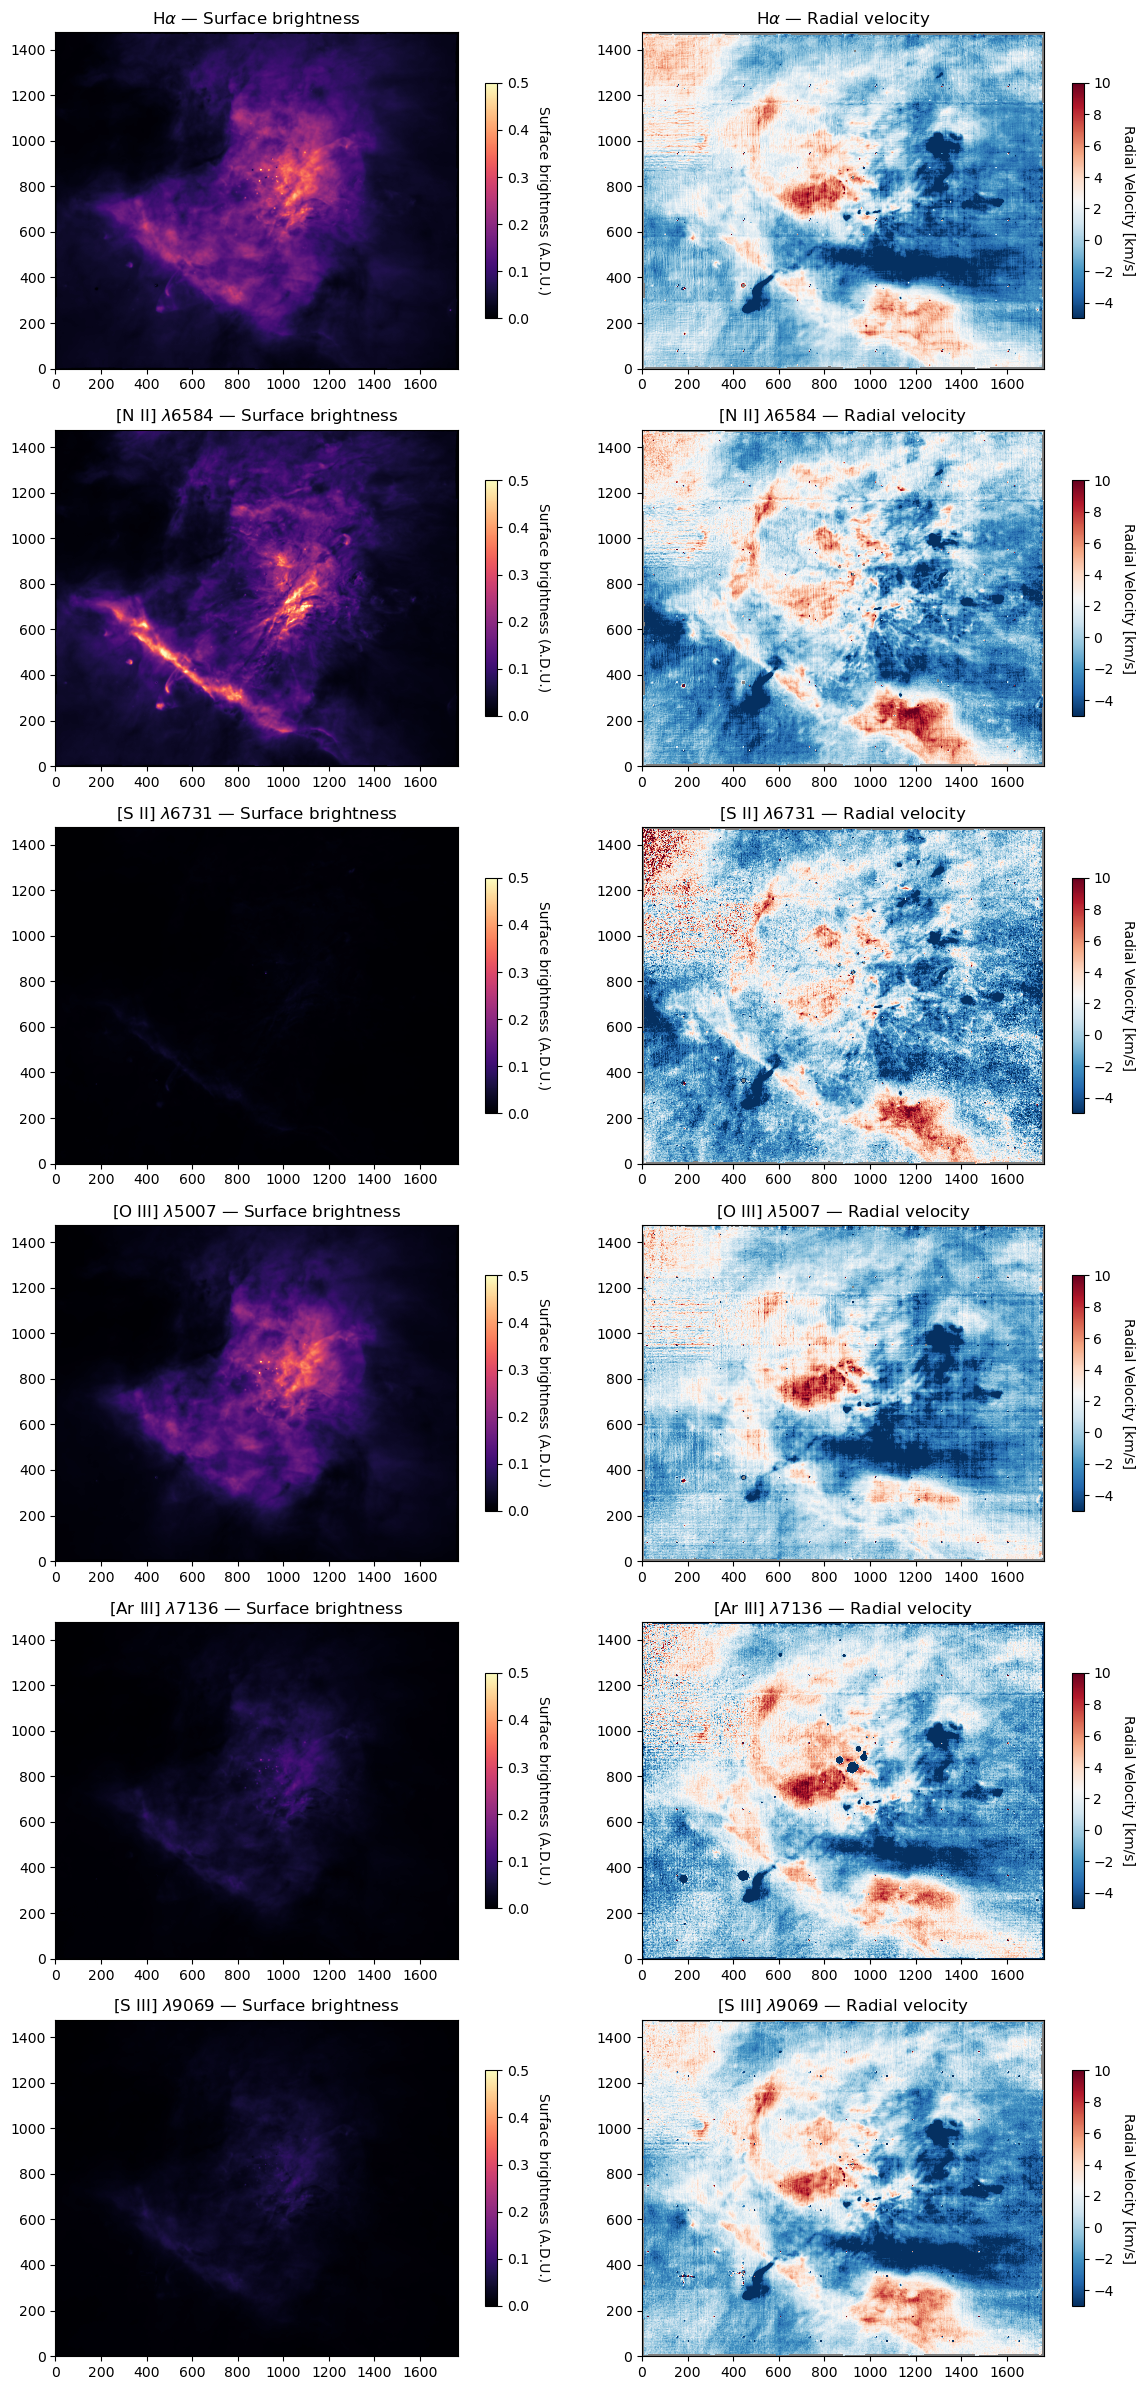

In [14]:
n_lines = len(selected_lines)

fig, axes = plt.subplots(
    n_lines,
    2,
    figsize=(12, 4 * n_lines),
    squeeze=False,
)

cmap_vv = plt.cm.RdBu_r.copy()
cmap_sb = plt.cm.magma.copy()

cmap_vv.set_bad(color="gray")
cmap_sb.set_bad(color="gray")

for i, line_key in enumerate(selected_lines):

    sb = line_data[line_key]["sb"]
    vv = line_data[line_key]["vv"]
    plot_label = line_data[line_key]["plot_label"]

    ax_sb = axes[i, 0]
    ax_vv = axes[i, 1]

    im_sb = ax_sb.imshow(
        sb,
        origin="lower",
        cmap=cmap_sb,
        vmin=0,
        vmax=0.5,
    )

    cbar_sb = fig.colorbar(
        im_sb,
        ax=ax_sb,
        shrink=0.7,
    )

    cbar_sb.set_label(
        "Surface brightness (A.D.U.)",
        rotation=270,
        labelpad=15,
    )

    im_vv = ax_vv.imshow(
        vv-np.nanmean(vv),
        origin="lower",
        cmap=cmap_vv,
        vmin=-5,
        vmax=10,
    )

    cbar_vv = fig.colorbar(
        im_vv,
        ax=ax_vv,
        shrink=0.7,
    )

    cbar_vv.set_label(
        "Radial Velocity [km/s]",
        rotation=270,
        labelpad=15,
    )

    ax_sb.set_title(f"{plot_label} — Surface brightness")
    ax_vv.set_title(f"{plot_label} — Radial velocity")

plt.tight_layout()
plt.show()

Velocity difference

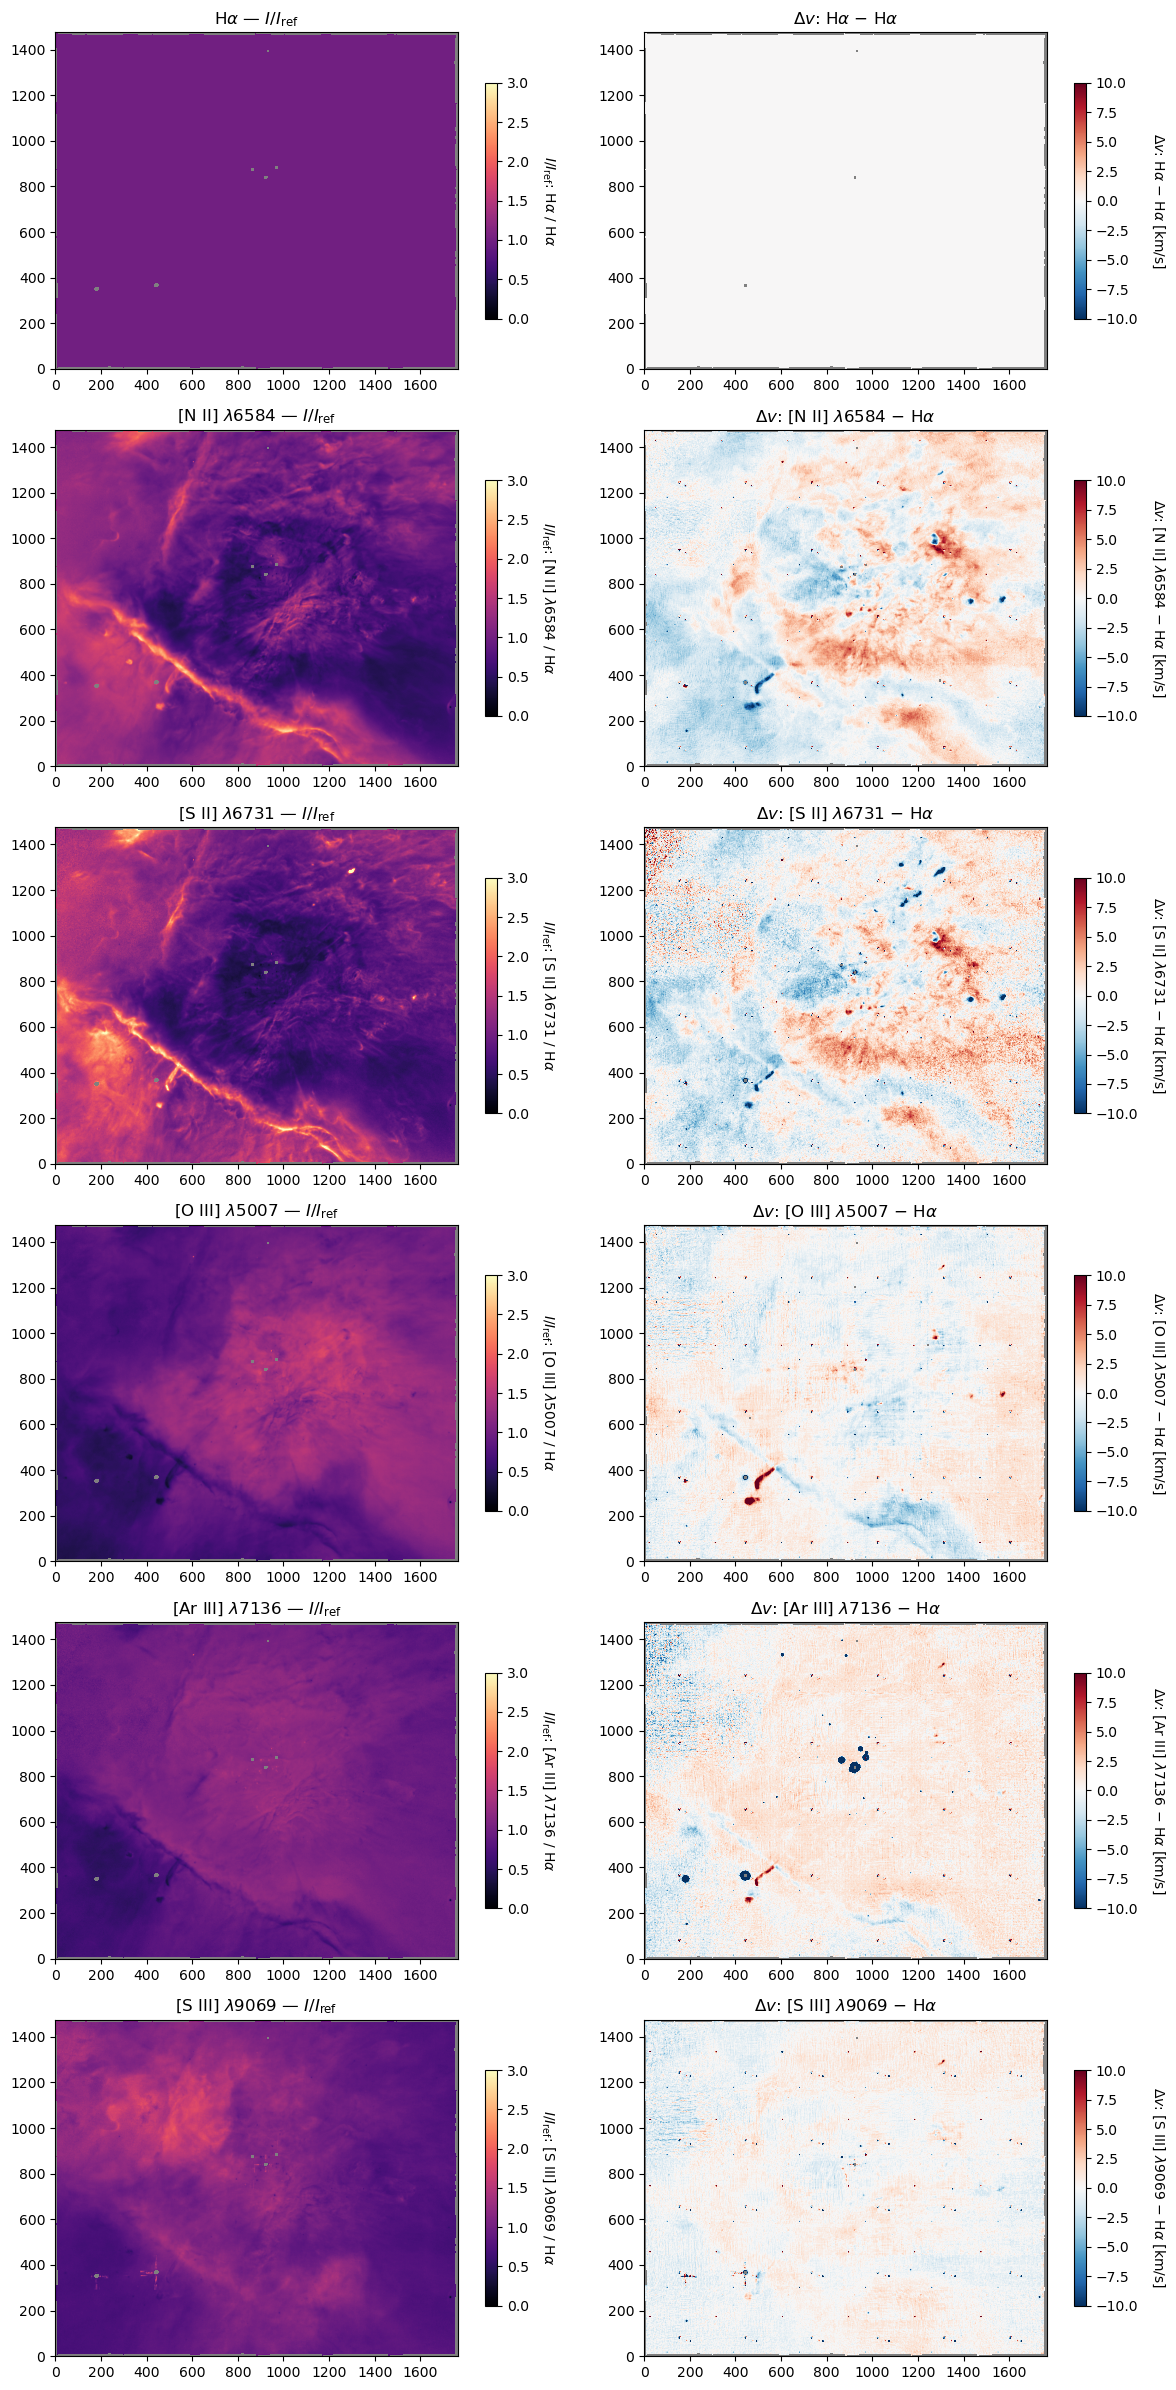

In [15]:
reference_line = "Halpha"   # Use None to plot original maps

n_lines = len(selected_lines)

fig, axes = plt.subplots(
    n_lines,
    2,
    figsize=(12, 4 * n_lines),
    squeeze=False,
)

cmap_vv = plt.cm.RdBu_r.copy()
cmap_sb = plt.cm.magma.copy()

cmap_vv.set_bad(color="gray")
cmap_sb.set_bad(color="gray")

# Reference maps
if reference_line is not None:
    vv_reference = line_data[reference_line]["vv"]
    sb_reference = line_data[reference_line]["sb"]
    reference_label = line_data[reference_line]["plot_label"]

for i, line_key in enumerate(selected_lines):

    sb = line_data[line_key]["sb"]
    vv = line_data[line_key]["vv"]
    plot_label = line_data[line_key]["plot_label"]

    if reference_line is None:
        sb_plot = sb
        vv_plot = vv

        sb_title = f"{plot_label} — Surface brightness"
        vv_title = f"{plot_label} — Radial velocity"

        sb_cbar_label = "Surface brightness (A.D.U.)"
        vv_cbar_label = "Radial velocity [km/s]"

    else:
        # Surface-brightness ratio, avoiding division by zero
        sb_plot = np.full_like(sb, np.nan, dtype=float)

        valid_sb = (
            np.isfinite(sb)
            & np.isfinite(sb_reference)
            & (sb_reference != 0)
        )

        np.divide(
            sb,
            sb_reference,
            out=sb_plot,
            where=valid_sb,
        )

        # Mean-centered velocity difference
        vv_plot = (
            vv - np.nanmean(vv)
        ) - (
            vv_reference - np.nanmean(vv_reference)
        )

        sb_title = rf"{plot_label} — $I/I_{{\mathrm{{ref}}}}$"
        vv_title = (
            rf"$\Delta v$: "
            f"{plot_label} − {reference_label} "
        )

        sb_cbar_label = (
            rf"$I/I_{{\mathrm{{ref}}}}$: "
            f"{plot_label} / {reference_label}"
        )
        
        vv_cbar_label = (
            rf"$\Delta v$: "
            f"{plot_label} − {reference_label} [km/s]"
        )

    ax_sb = axes[i, 0]
    ax_vv = axes[i, 1]

    im_sb = ax_sb.imshow(
        sb_plot/np.nanmedian(sb_plot),
        origin="lower",
        cmap=cmap_sb,
        vmin=0,
        vmax=3.0,
    )

    cbar_sb = fig.colorbar(
        im_sb,
        ax=ax_sb,
        shrink=0.7,
    )

    cbar_sb.set_label(
        sb_cbar_label,
        rotation=270,
        labelpad=20,

    )

    im_vv = ax_vv.imshow(
        vv_plot,
        origin="lower",
        cmap=cmap_vv,
        vmin=-10,
        vmax=10,
    )

    cbar_vv = fig.colorbar(
        im_vv,
        ax=ax_vv,
        shrink=0.7,
    )

    cbar_vv.set_label(
        vv_cbar_label,
        rotation=270,
        labelpad=20,
    )

    ax_sb.set_title(sb_title)
    ax_vv.set_title(vv_title)

plt.tight_layout()
plt.show()

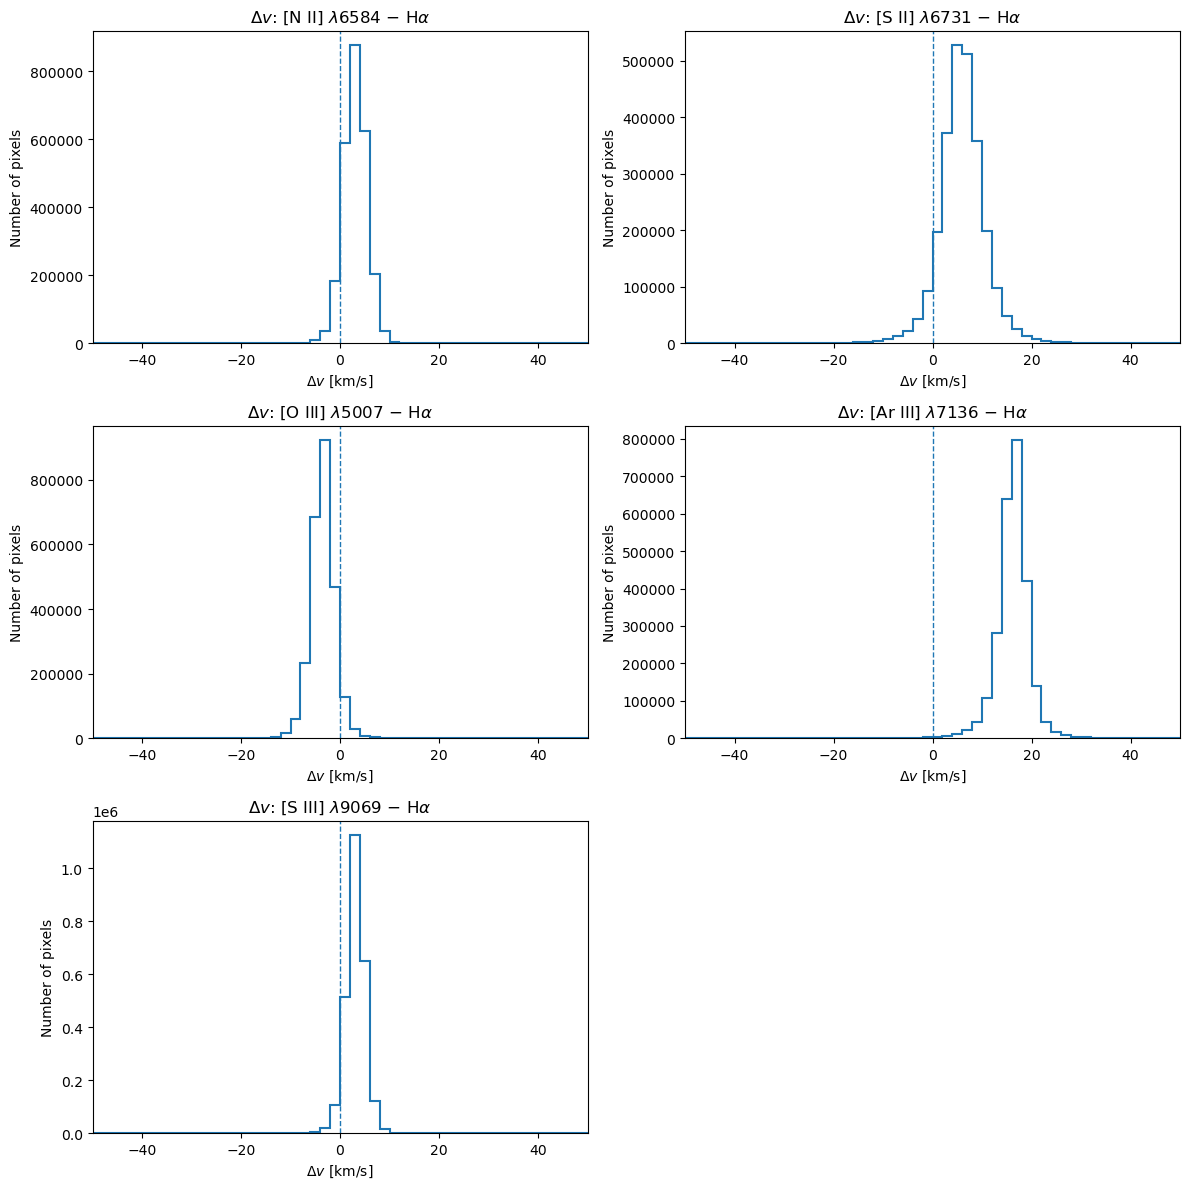

In [16]:
reference_line = "Halpha"

vv_reference = line_data[reference_line]["vv"]
reference_label = line_data[reference_line]["plot_label"]

lines_to_plot = [
    line_key
    for line_key in selected_lines
    if line_key != reference_line
]

n_lines = len(lines_to_plot)
n_cols = 2
n_rows = int(np.ceil(n_lines / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows),
    squeeze=False,
)

axes = axes.ravel()

for ax, line_key in zip(axes, lines_to_plot):

    vv = line_data[line_key]["vv"]
    plot_label = line_data[line_key]["plot_label"]

    delta_v = vv - vv_reference

    # Keep only finite values
    delta_v_valid = delta_v[np.isfinite(delta_v)]

    ax.hist(
        delta_v_valid,
        bins=100,
        histtype="step",
        linewidth=1.5,
        range=(-100, 100),
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_xlim(-50, 50)

    ax.set_title(
        rf"$\Delta v$: {plot_label} − {reference_label}"
    )
    ax.set_xlabel(r"$\Delta v$ [km/s]")
    ax.set_ylabel("Number of pixels")

# Remove unused axes
for ax in axes[n_lines:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [17]:
import numpy as np
import pandas as pd

# Use the first line to obtain the map dimensions
ny, nx = line_data[selected_lines[0]]["sb"].shape

# Pixel coordinates
x, y = np.meshgrid(
    np.arange(nx),
    np.arange(ny),
)

# Initial dataframe
df_maps = pd.DataFrame({
    "x": x.ravel(),
    "y": y.ravel(),
})

# Add surface-brightness and velocity columns for every line
for line_key in selected_lines:

    sb = line_data[line_key]["sb"]
    vv = line_data[line_key]["vv"]

    if sb.shape != (ny, nx) or vv.shape != (ny, nx):
        raise ValueError(
            f"{line_key} has incompatible dimensions: "
            f"sb={sb.shape}, vv={vv.shape}, expected={(ny, nx)}"
        )

    df_maps[f"sb_{line_key}"] = sb.ravel()
    df_maps[f"vv_{line_key}"] = vv.ravel()

In [18]:
df_maps.describe()

,x,y,sb_Halpha,vv_Halpha,sb_NII_6583,vv_NII_6583,sb_SII_6731,vv_SII_6731,sb_OIII_5007,vv_OIII_5007,sb_ArIII_7136,vv_ArIII_7136,sb_SIII_9069,vv_SIII_9069
count,2.606616e+06,2.606616e+06,2.606616e+06,2.570283e+06,2.606616e+06,2.570320e+06,2.606616e+06,2.570363e+06,2.606616e+06,2.570110e+06,2.606616e+06,2.606616e+06,2.606616e+06,2.570384e+06
mean,8.825000e+02,7.375000e+02,7.155653e-02,1.407636e+01,6.723771e-02,1.711642e+01,5.219547e-03,2.012335e+01,5.314578e-02,1.063969e+01,1.961079e-02,2.979587e+01,1.519942e-02,1.717365e+01
std,5.098003e+02,4.260845e+02,6.145139e-02,9.706284e+00,6.084653e-02,9.016094e+00,4.201737e-03,1.483602e+01,5.720242e-02,1.616007e+01,1.958229e-02,6.483640e+00,1.433883e-02,2.972501e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-9.445588e+03,0.000000e+00,-9.557525e+03,0.000000e+00,-7.749528e+03,0.000000e+00,-8.256324e+03,0.000000e+00,-1.591335e+03,0.000000e+00,-1.690391e+04
25%,4.410000e+02,3.687500e+02,3.062927e-02,1.217710e+01,2.771652e-02,1.499022e+01,2.529708e-03,1.714745e+01,1.626202e-02,8.684010e+00,6.497584e-03,2.761628e+01,5.132616e-03,1.511814e+01
50%,8.825000e+02,7.375000e+02,4.621635e-02,1.406111e+01,5.036533e-02,1.701350e+01,4.410042e-03,2.001188e+01,2.906343e-02,1.055889e+01,1.127298e-02,3.020538e+01,9.211286e-03,1.720186e+01
75%,1.324000e+03,1.106250e+03,9.968495e-02,1.605405e+01,8.580690e-02,1.915029e+01,6.664196e-03,2.294605e+01,7.283305e-02,1.251201e+01,2.737519e-02,3.269928e+01,2.163290e-02,1.928303e+01
max,1.765000e+03,1.475000e+03,1.000000e+00,7.020826e+03,1.000000e+00,1.269212e+03,1.000000e+00,1.271465e+04,1.000000e+00,1.887998e+04,1.000000e+00,8.809617e+02,1.000000e+00,4.252871e+04


Histograms

In [19]:
vel_01 = df_maps['vv_Halpha']
vel_02 = df_maps['vv_NII_6583']

In [20]:
ymin, ymax = -10, 40
xmin, xmax = -10, 40

In [21]:
H, yedges, xedges = np.histogram2d(
    vel_02,
    vel_01,
    bins = 1000,
    range = [[ymin, ymax],[xmin, xmax]],
    density = True,
)

In [22]:
HH = np.where(H ==0.0, np.nan, H)

[Text(0.5, 0, 'Halpha'),
 Text(0, 0.5, 'NII_6583'),
 Text(0.5, 1.0, 'Velocity comparison')]

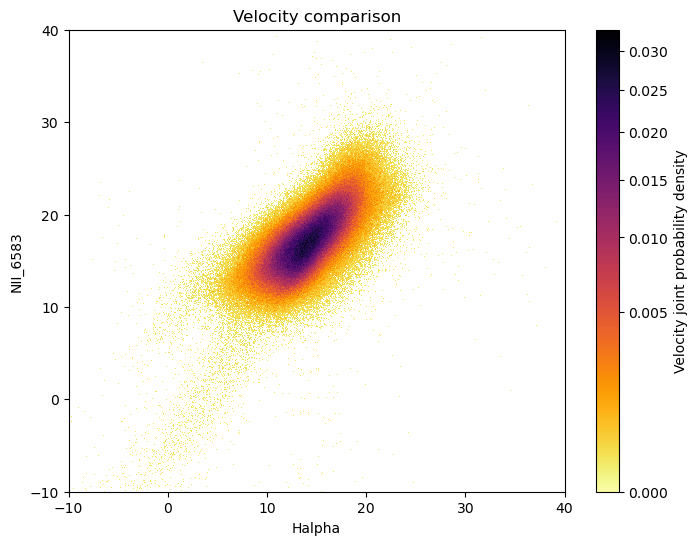

In [23]:
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize =(8, 6))
im = ax.imshow(
    HH,
    origin = 'lower',
    norm = PowerNorm(gamma = 0.5, vmin =0.0),
    cmap = 'inferno_r',
    extent = [xmin, xmax, ymin, ymax],
    aspect = 'auto',
    interpolation = 'none',
)

fig.colorbar(im, ax=ax, label = 'Velocity joint probability density')
ax.set(
    xlabel = 'Halpha',
    ylabel = 'NII_6583',
    title = 'Velocity comparison'
)

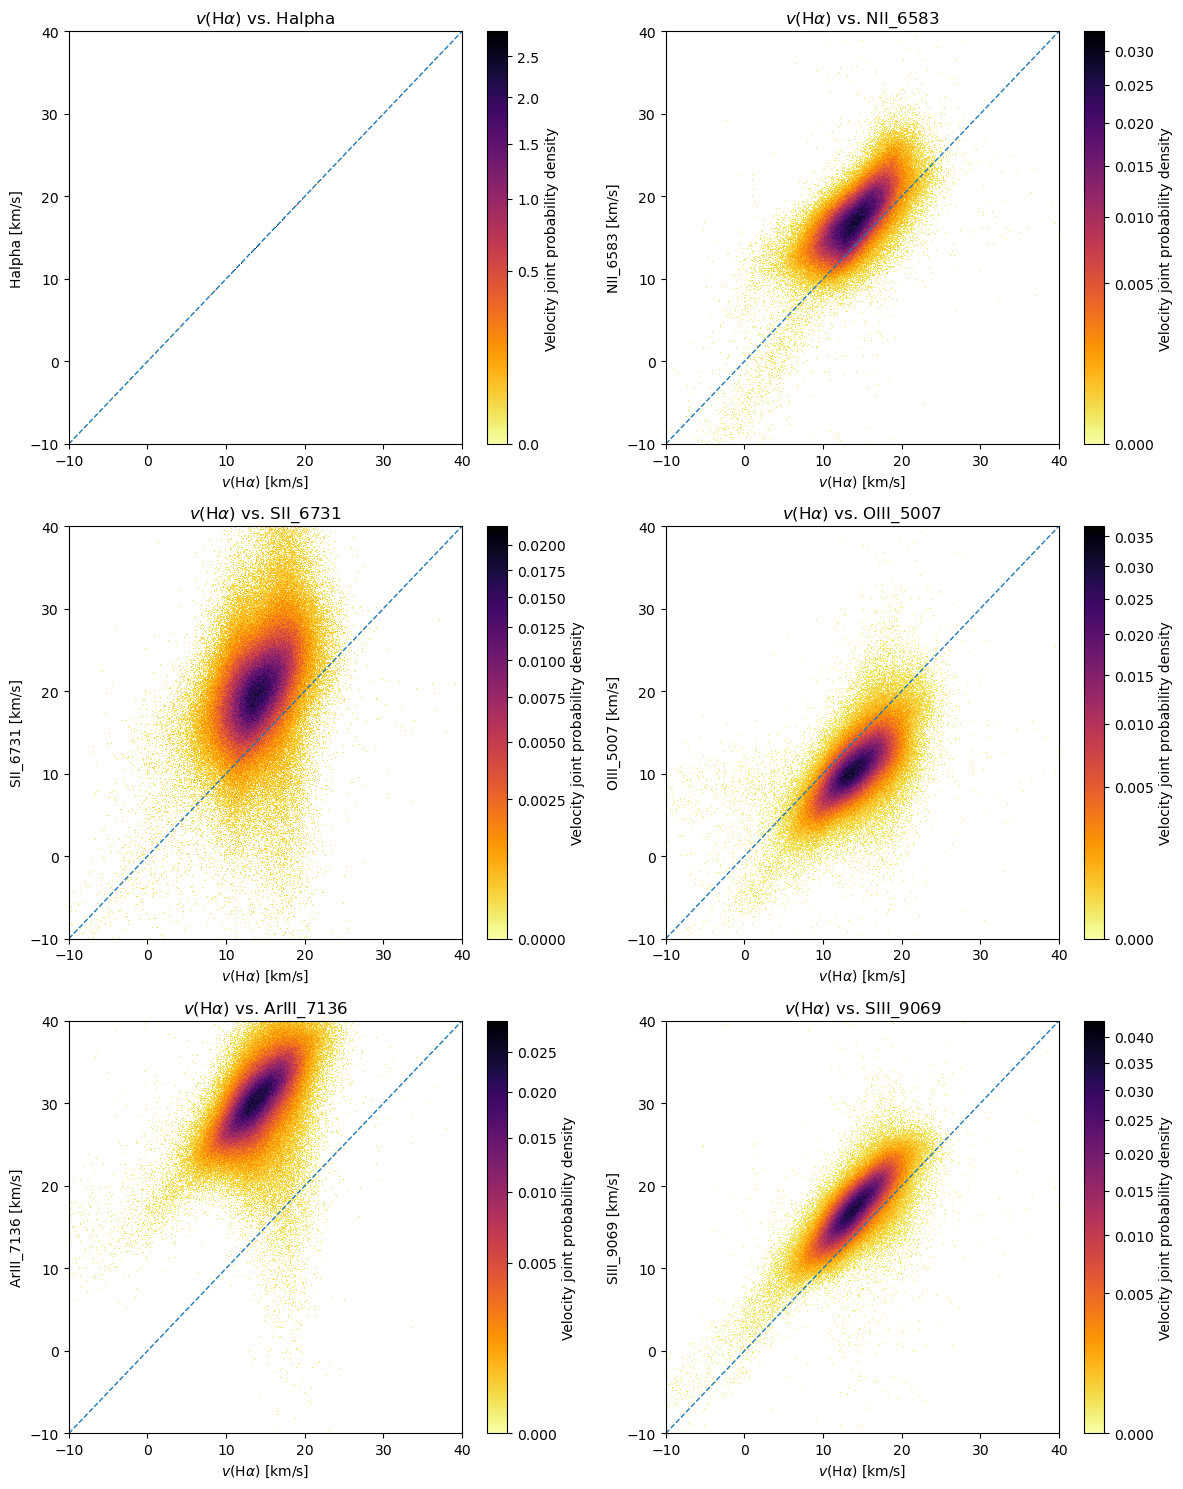

In [24]:
from matplotlib.colors import PowerNorm

reference_column = "vv_Halpha"

vv_columns = [
    column
    for column in df_maps.columns
    if column.startswith("vv_")
]

ymin, ymax = -10, 40
xmin, xmax = -10, 40

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 15),
    squeeze=False,
)

axes = axes.ravel()

for ax, column in zip(axes, vv_columns):

    vel_ref = df_maps[reference_column].to_numpy()
    vel_x = df_maps[column].to_numpy()

    # Pixels must be valid in both velocity maps
    valid = np.isfinite(vel_ref) & np.isfinite(vel_x)

    H, yedges, xedges = np.histogram2d(
        vel_x[valid],
        vel_ref[valid],
        bins=1000,
        range=[[ymin, ymax], [xmin, xmax]],
        density=True,
    )

    HH = np.where(H == 0.0, np.nan, H)

    im = ax.imshow(
        HH,
        origin="lower",
        norm=PowerNorm(gamma=0.5, vmin=0.0),
        cmap="inferno_r",
        extent=[xmin, xmax, ymin, ymax],
        aspect="auto",
        interpolation="none",
    )

    line_name = column.removeprefix("vv_")

    fig.colorbar(
        im,
        ax=ax,
        label="Velocity joint probability density",
    )

    ax.plot(
        [xmin, xmax],
        [ymin, ymax],
        linestyle="--",
        linewidth=1,
    )

    ax.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        xlabel=r"$v(\mathrm{H}\alpha)$ [km/s]",
        ylabel=f"{line_name} [km/s]",
        title=rf"$v(\mathrm{{H}}\alpha)$ vs. {line_name}",
    )

plt.tight_layout()
plt.show()

Downsample

In [25]:
import numpy as np


def make_binned_maps(sb, vv, bin_levels=(1, 2, 3, 4), mingood=1):
    """
    Downsample surface-brightness and velocity maps.

    Each level starts from the original sb and vv maps. A level of N applies
    the downsample function N times.

    Returns
    -------
    dict
        Keys such as:
        sb_1, vv_1, sb_2, vv_2, ...
    """

    results = {}

    for level in bin_levels:

        # Start from the original maps at every level
        sb_bin = np.asarray(sb, dtype=float).copy()
        vv_bin = np.asarray(vv, dtype=float).copy()

        # Intensity-weighted velocity numerator
        prod_bin = sb_bin * vv_bin

        # Valid-pixel masks
        sb_valid = np.isfinite(sb_bin)
        prod_valid = np.isfinite(sb_bin) & np.isfinite(vv_bin)

        # Apply downsampling repeatedly
        for _ in range(level):

            [sb_bin], sb_valid = downsample(
                [sb_bin],
                sb_valid,
                mingood=mingood,
            )

            [prod_bin], prod_valid = downsample(
                [prod_bin],
                prod_valid,
                mingood=mingood,
            )

        # Recover the intensity-weighted velocity
        vv_binned = np.full_like(prod_bin, np.nan, dtype=float)

        valid_division = (
            np.isfinite(prod_bin)
            & np.isfinite(sb_bin)
            & (sb_bin != 0)
        )

        np.divide(
            prod_bin,
            sb_bin,
            out=vv_binned,
            where=valid_division,
        )

        results[f"sb_{level}"] = sb_bin
        results[f"vv_{level}"] = vv_binned

    return results

In [26]:
bin_levels = (1, 2, 3, 4)

line_data_binned = {}

for line_key in selected_lines:

    sb = line_data[line_key]["sb"]
    vv = line_data[line_key]["vv"]

    binned_maps = make_binned_maps(
        sb=sb,
        vv=vv,
        bin_levels=bin_levels,
        mingood=1,
    )

    line_data_binned[line_key] = {
        "plot_label": line_data[line_key]["plot_label"],
        **binned_maps,
    }

C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\structure_function_analysis\MUSE_orion\rebin_utils.py:107: RuntimeWarning: invalid value encountered in divide
  (


In [27]:
line_data_binned[selected_lines[1]]["sb_2"]

array([[0.        , 0.01792381, 0.02446575, ..., 0.00209788, 0.        ,
        0.        ],
       [0.        , 0.02432922, 0.03212414, ..., 0.01090835, 0.        ,
        0.        ],
       [0.        , 0.023552  , 0.03201182, ..., 0.01132274, 0.0021735 ,
        0.        ],
       ...,
       [0.00339917, 0.00568171, 0.00550603, ..., 0.01441266, 0.01310478,
        0.00472714],
       [0.00256982, 0.00524367, 0.00528858, ..., 0.        , 0.        ,
        0.        ],
       [0.0017566 , 0.00366984, 0.00332091, ..., 0.        , 0.        ,
        0.        ]])

In [28]:
line_data_binned[selected_lines[1]]["vv_2"]

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan, 17.84503055, ...,         nan,
                nan,         nan],
       [        nan,         nan, 17.60385473, ...,         nan,
                nan,         nan],
       ...,
       [        nan, 21.60198288, 21.63444567, ...,         nan,
        38.70253898,         nan],
       [52.72150103, 25.23884319, 27.99844708, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])

In [29]:
selected_lines = ["Halpha", "NII_6583", "SII_6731","OIII_5007",'ArIII_7136',"SIII_9069"]

In [30]:
selected_lines[0]

'Halpha'

In [31]:
import numpy as np
import pandas as pd


def make_binned_dataframes(
    line_data_binned,
    selected_lines,
    bin_levels=(1, 2, 3, 4),
):
    """
    Create one dataframe for each binning level.

    Returns
    -------
    dict
        Keys are binning levels:
        df_maps_binned[1], df_maps_binned[2], etc.
    """

    df_maps_binned = {}

    for level in bin_levels:

        sb_key = f"sb_{level}"
        vv_key = f"vv_{level}"

        # Use the first line to determine the binned map dimensions
        first_line = selected_lines[0]
        ny, nx = line_data_binned[first_line][sb_key].shape

        # Pixel coordinates for this binning level
        x, y = np.meshgrid(
            np.arange(nx),
            np.arange(ny),
        )

        df_level = pd.DataFrame({
            "x": x.ravel(),
            "y": y.ravel(),
        })

        for line_key in selected_lines:

            sb = line_data_binned[line_key][sb_key]
            vv = line_data_binned[line_key][vv_key]

            if sb.shape != (ny, nx) or vv.shape != (ny, nx):
                raise ValueError(
                    f"{line_key}, bin level {level}, has incompatible dimensions: "
                    f"sb={sb.shape}, vv={vv.shape}, expected={(ny, nx)}"
                )

            df_level[f"sb_{line_key}"] = sb.ravel()
            df_level[f"vv_{line_key}"] = vv.ravel()

        df_maps_binned[level] = df_level

    return df_maps_binned

In [32]:
df_maps_binned = make_binned_dataframes(
    line_data_binned=line_data_binned,
    selected_lines=selected_lines,
    bin_levels=(1, 2, 3, 4),
)

In [33]:
df_maps_1 = df_maps_binned[1]
df_maps_2 = df_maps_binned[2]
df_maps_3 = df_maps_binned[3]
df_maps_4 = df_maps_binned[4]

In [34]:
df_maps

,x,y,sb_Halpha,vv_Halpha,sb_NII_6583,vv_NII_6583,sb_SII_6731,vv_SII_6731,sb_OIII_5007,vv_OIII_5007,sb_ArIII_7136,vv_ArIII_7136,sb_SIII_9069,vv_SIII_9069
0,0,0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
1,1,0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
2,2,0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
3,3,0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
4,4,0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2606611,1761,1475,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
2606612,1762,1475,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
2606613,1763,1475,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN
2606614,1764,1475,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm


def plot_velocity_comparison(
    df_input,
    reference_column="vv_Halpha",
    xmin=-10,
    xmax=40,
    ymin=-10,
    ymax=40,
    bins=1000,
    n_cols=2,
):
    vv_columns = [
        column
        for column in df_input.columns
        if column.startswith("vv_")
    ]

    if reference_column not in vv_columns:
        raise KeyError(
            f"{reference_column!r} is not present in the dataframe."
        )

    n_plots = len(vv_columns)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    vel_ref = df_input[reference_column].to_numpy()
    reference_name = reference_column.removeprefix("vv_")

    for ax, column in zip(axes, vv_columns):

        vel_x = df_input[column].to_numpy()

        valid = (
            np.isfinite(vel_ref)
            & np.isfinite(vel_x)
        )

        H, yedges, xedges = np.histogram2d(
            vel_x[valid],
            vel_ref[valid],
            bins=bins,
            range=[
                [ymin, ymax],
                [xmin, xmax],
            ],
            density=True,
        )

        HH = np.where(H == 0.0, np.nan, H)

        im = ax.imshow(
            HH,
            origin="lower",
            norm=PowerNorm(
                gamma=0.5,
                vmin=0.0,
            ),
            cmap="inferno_r",
            extent=[
                xmin,
                xmax,
                ymin,
                ymax,
            ],
            aspect="auto",
            interpolation="none",
        )

        line_name = column.removeprefix("vv_")

        fig.colorbar(
            im,
            ax=ax,
            label="Velocity joint probability density",
        )

        ax.plot(
            [xmin, xmax],
            [ymin, ymax],
            linestyle="--",
            linewidth=1,
        )

        ax.set(
            xlim=(xmin, xmax),
            ylim=(ymin, ymax),
            xlabel=f"{reference_name} [km/s]",
            ylabel=f"{line_name} [km/s]",
            title=f"{reference_name} vs. {line_name}",
        )

    for ax in axes[n_plots:]:
        ax.remove()

    plt.tight_layout()
    plt.show()

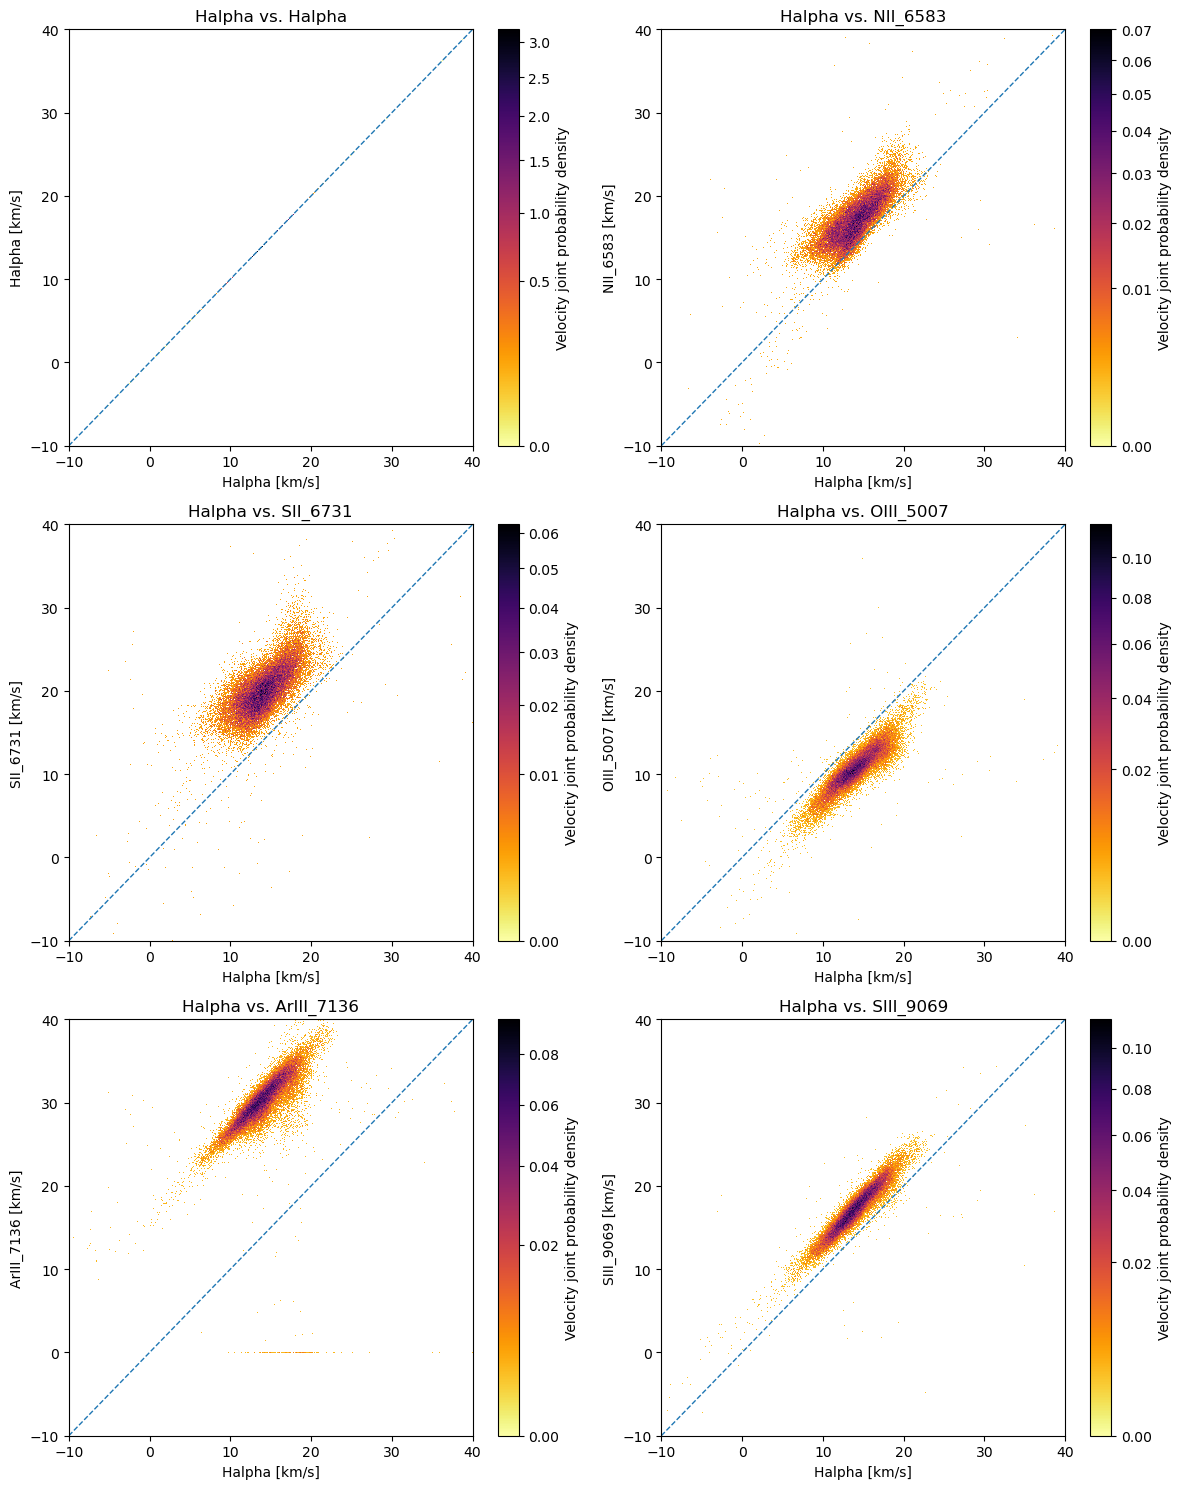

In [36]:
plot_velocity_comparison(df_maps_2)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm


def plot_sb_ratio_vs_velocity_difference(
    line_data,
    selected_lines,
    *,
    reference_line="Halpha",
    ratio_min=0,
    ratio_max=3,
    velocity_min=-10,
    velocity_max=10,
    bins=300,
    n_cols=2,
    normalize_ratio=True,
    include_reference=False,
):
    """
    Plot joint-density histograms between:

        x = I_line / I_reference

    optionally normalized by its median, and

        y = (v_line - mean(v_line))
            - (v_reference - mean(v_reference)).
    """

    # Labels safe for use inside Matplotlib math expressions
    math_labels = {
        "Halpha": r"\mathrm{H}\alpha",
        "NII_6583": r"\mathrm{[N\,II]}",
        "OIII_5007": r"\mathrm{[O\,III]}",
        "SII_6731": r"\mathrm{[S\,II]}",
        "SIII_9069": r"\mathrm{[S\,III]}",
        "ArIII_7136": r"\mathrm{[Ar\,III]}",
    }

    if reference_line not in line_data:
        raise KeyError(
            f"Reference line {reference_line!r} "
            "is not present in line_data."
        )

    lines_to_plot = list(selected_lines)

    if not include_reference:
        lines_to_plot = [
            line_key
            for line_key in lines_to_plot
            if line_key != reference_line
        ]

    if not lines_to_plot:
        raise ValueError("There are no emission lines to plot.")

    sb_reference = np.asarray(
        line_data[reference_line]["sb"],
        dtype=float,
    )
    vv_reference = np.asarray(
        line_data[reference_line]["vv"],
        dtype=float,
    )

    reference_label = line_data[reference_line]["plot_label"]
    reference_math = math_labels.get(
        reference_line,
        rf"\mathrm{{{reference_line}}}",
    )

    vv_reference_mean = np.nanmean(vv_reference)
    vv_reference_centered = (
        vv_reference - vv_reference_mean
    )

    n_plots = len(lines_to_plot)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.5 * n_cols, 5 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, line_key in zip(axes, lines_to_plot):

        if line_key not in line_data:
            raise KeyError(
                f"Line {line_key!r} is not present in line_data."
            )

        sb = np.asarray(
            line_data[line_key]["sb"],
            dtype=float,
        )
        vv = np.asarray(
            line_data[line_key]["vv"],
            dtype=float,
        )

        if sb.shape != sb_reference.shape:
            raise ValueError(
                f"Surface-brightness maps for {line_key!r} and "
                f"{reference_line!r} have different shapes: "
                f"{sb.shape} and {sb_reference.shape}."
            )

        if vv.shape != vv_reference.shape:
            raise ValueError(
                f"Velocity maps for {line_key!r} and "
                f"{reference_line!r} have different shapes: "
                f"{vv.shape} and {vv_reference.shape}."
            )

        plot_label = line_data[line_key]["plot_label"]
        line_math = math_labels.get(
            line_key,
            rf"\mathrm{{{line_key}}}",
        )

        # -----------------------------------------------------
        # Surface-brightness ratio
        # -----------------------------------------------------
        sb_ratio = np.full_like(
            sb,
            np.nan,
            dtype=float,
        )

        valid_sb = (
            np.isfinite(sb)
            & np.isfinite(sb_reference)
            & (sb_reference != 0)
        )

        np.divide(
            sb,
            sb_reference,
            out=sb_ratio,
            where=valid_sb,
        )

        if normalize_ratio:
            ratio_median = np.nanmedian(sb_ratio)

            if (
                not np.isfinite(ratio_median)
                or ratio_median == 0
            ):
                raise ValueError(
                    f"The median intensity ratio for "
                    f"{line_key!r} is invalid."
                )

            sb_ratio = sb_ratio / ratio_median

        # -----------------------------------------------------
        # Mean-centered velocity difference
        # -----------------------------------------------------
        vv_centered = vv - np.nanmean(vv)

        velocity_difference = (
            vv_centered - vv_reference_centered
        )

        # Use pixels valid in both quantities and inside
        # the requested plotting range
        valid = (
            np.isfinite(sb_ratio)
            & np.isfinite(velocity_difference)
            & (sb_ratio >= ratio_min)
            & (sb_ratio <= ratio_max)
            & (velocity_difference >= velocity_min)
            & (velocity_difference <= velocity_max)
        )

        if not np.any(valid):
            ax.text(
                0.5,
                0.5,
                "No valid pixels",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        # -----------------------------------------------------
        # Two-dimensional density histogram
        # -----------------------------------------------------
        H, ratio_edges, velocity_edges = np.histogram2d(
            sb_ratio[valid],
            velocity_difference[valid],
            bins=bins,
            range=[
                [ratio_min, ratio_max],
                [velocity_min, velocity_max],
            ],
            density=True,
        )

        # Transpose so the first variable is displayed along x
        density = H.T
        density = np.where(
            density > 0,
            density,
            np.nan,
        )

        im = ax.imshow(
            density,
            origin="lower",
            extent=[
                ratio_edges[0],
                ratio_edges[-1],
                velocity_edges[0],
                velocity_edges[-1],
            ],
            aspect="auto",
            interpolation="none",
            cmap="inferno_r",
            norm=PowerNorm(
                gamma=0.5,
                vmin=0,
            ),
        )

        cbar = fig.colorbar(
            im,
            ax=ax,
            shrink=0.85,
        )
        cbar.set_label(
            "Joint probability density",
            rotation=270,
            labelpad=18,
        )

        # Reference lines
        if normalize_ratio:
            ax.axvline(
                1,
                color="tab:blue",
                linestyle="--",
                linewidth=1,
            )

        ax.axhline(
            0,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
        )

        # Math-safe axis labels
        if normalize_ratio:
            xlabel = (
                rf"$\left(I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}\right)"
                rf"\,/\,\operatorname{{median}}\left("
                rf"I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}\right)$"
            )
        else:
            xlabel = (
                rf"$I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}$"
            )

        ylabel = (
            rf"$\Delta v = "
            rf"(v_{{{line_math}}}-"
            rf"\overline{{v}}_{{{line_math}}})"
            rf"-(v_{{{reference_math}}}-"
            rf"\overline{{v}}_{{{reference_math}}})$"
            rf" [km s$^{{-1}}$]"
        )

        ax.set(
            xlim=(ratio_min, ratio_max),
            ylim=(velocity_min, velocity_max),
            xlabel=xlabel,
            ylabel=ylabel,
            title=f"{plot_label} relative to {reference_label}",
        )

    # Remove empty subplot positions
    for ax in axes[n_plots:]:
        ax.remove()

    fig.tight_layout()
    plt.show()

    return fig, axes[:n_plots]

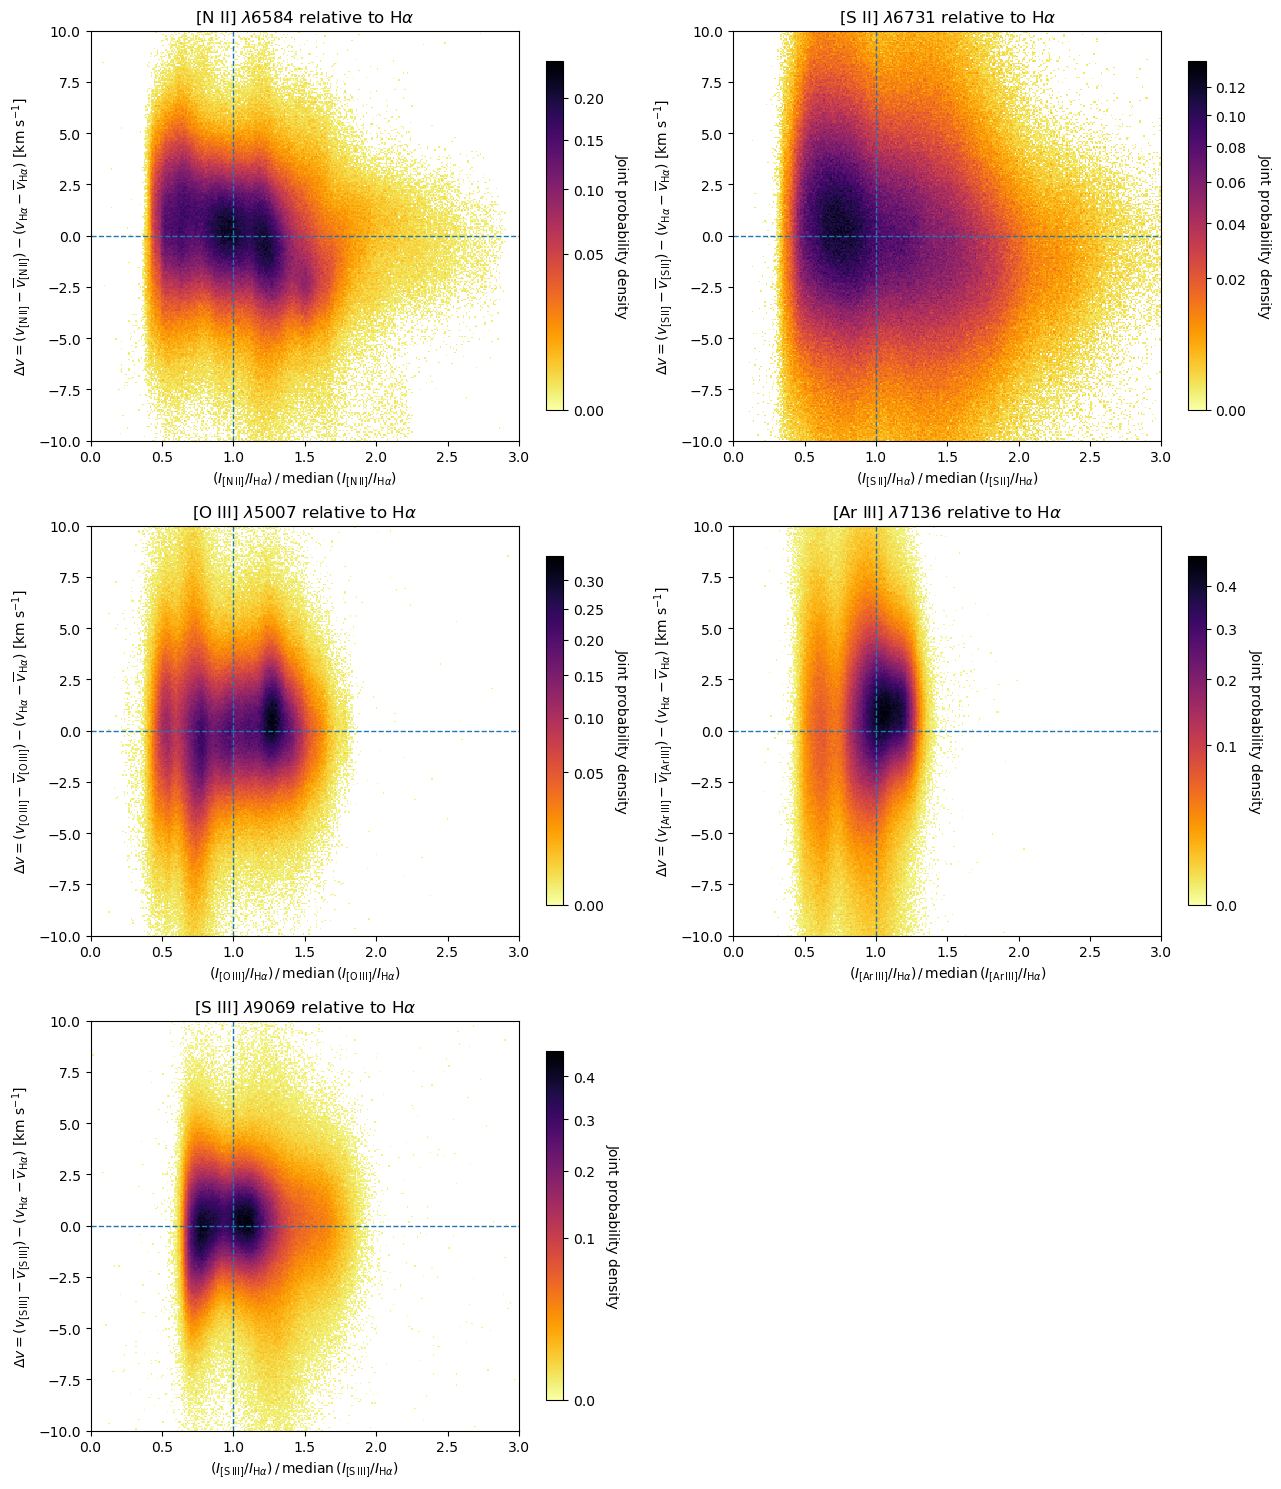

In [41]:
fig, axes = plot_sb_ratio_vs_velocity_difference(
    line_data,
    selected_lines,
    reference_line="Halpha",
    ratio_min=0,
    ratio_max=3,
    velocity_min=-10,
    velocity_max=10,
    bins=300,
    n_cols=2,
    normalize_ratio=True,
    include_reference=False,
)

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm


def plot_sb_ratio_vs_velocity_difference(
    line_data,
    selected_lines,
    *,
    reference_line="Halpha",
    binning=4,
    ratio_min=0,
    ratio_max=3,
    velocity_min=-10,
    velocity_max=10,
    hist_bins=300,
    n_cols=2,
    normalize_ratio=True,
    include_reference=False,
):
    """
    Plot 2D joint-density histograms between the surface-brightness
    ratio and the mean-centered velocity difference.

    Parameters
    ----------
    binning : int or None
        Spatial binning of the maps. For example, binning=4 uses
        the keys "sb_4" and "vv_4". If None, it uses "sb" and "vv".

    hist_bins : int
        Number of bins used in the 2D histogram. This is independent
        of the spatial map binning.
    """

    math_labels = {
        "Halpha": r"\mathrm{H}\alpha",
        "NII_6583": r"\mathrm{[N\,II]}",
        "OIII_5007": r"\mathrm{[O\,III]}",
        "SII_6731": r"\mathrm{[S\,II]}",
        "SIII_9069": r"\mathrm{[S\,III]}",
        "ArIII_7136": r"\mathrm{[Ar\,III]}",
    }

    # Select the appropriate map keys
    if binning is None:
        sb_key = "sb"
        vv_key = "vv"
        binning_label = "original resolution"
    else:
        sb_key = f"sb_{binning}"
        vv_key = f"vv_{binning}"
        binning_label = f"{2**binning}×{2**binning} binning"

    if reference_line not in line_data:
        raise KeyError(
            f"Reference line {reference_line!r} is not in line_data."
        )

    # Check that the requested maps exist
    for key in (sb_key, vv_key):
        if key not in line_data[reference_line]:
            raise KeyError(
                f"{key!r} is not available for {reference_line!r}."
            )

    lines_to_plot = list(selected_lines)

    if not include_reference:
        lines_to_plot = [
            line_key
            for line_key in lines_to_plot
            if line_key != reference_line
        ]

    if not lines_to_plot:
        raise ValueError("There are no emission lines to plot.")

    # Reference maps
    sb_reference = np.asarray(
        line_data[reference_line][sb_key],
        dtype=float,
    )

    vv_reference = np.asarray(
        line_data[reference_line][vv_key],
        dtype=float,
    )

    reference_label = line_data[reference_line]["plot_label"]

    reference_math = math_labels.get(
        reference_line,
        rf"\mathrm{{{reference_line}}}",
    )

    vv_reference_centered = (
        vv_reference - np.nanmean(vv_reference)
    )

    n_plots = len(lines_to_plot)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.5 * n_cols, 5 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, line_key in zip(axes, lines_to_plot):

        if line_key not in line_data:
            raise KeyError(
                f"Line {line_key!r} is not in line_data."
            )

        for key in (sb_key, vv_key):
            if key not in line_data[line_key]:
                raise KeyError(
                    f"{key!r} is not available for {line_key!r}."
                )

        sb = np.asarray(
            line_data[line_key][sb_key],
            dtype=float,
        )

        vv = np.asarray(
            line_data[line_key][vv_key],
            dtype=float,
        )

        if sb.shape != sb_reference.shape:
            raise ValueError(
                f"The {sb_key} maps for {line_key!r} and "
                f"{reference_line!r} have different shapes: "
                f"{sb.shape} and {sb_reference.shape}."
            )

        if vv.shape != vv_reference.shape:
            raise ValueError(
                f"The {vv_key} maps for {line_key!r} and "
                f"{reference_line!r} have different shapes: "
                f"{vv.shape} and {vv_reference.shape}."
            )

        plot_label = line_data[line_key]["plot_label"]

        line_math = math_labels.get(
            line_key,
            rf"\mathrm{{{line_key}}}",
        )

        # Surface-brightness ratio
        sb_ratio = np.full_like(
            sb,
            np.nan,
            dtype=float,
        )

        valid_sb = (
            np.isfinite(sb)
            & np.isfinite(sb_reference)
            & (sb_reference != 0)
        )

        np.divide(
            sb,
            sb_reference,
            out=sb_ratio,
            where=valid_sb,
        )

        # Normalize ratio by its median
        if normalize_ratio:
            ratio_median = np.nanmedian(sb_ratio)
#            ratio_median = np.nanmedian(sb)

            if (
                not np.isfinite(ratio_median)
                or ratio_median == 0
            ):
                raise ValueError(
                    f"Invalid median intensity ratio for {line_key!r}."
                )

            sb_ratio = sb_ratio / ratio_median

        # Mean-centered velocity difference
        vv_centered = vv - np.nanmean(vv)

        velocity_difference = (
            vv_centered - vv_reference_centered
        )

        # Select finite values within the plotting range
        valid = (
            np.isfinite(sb_ratio)
            & np.isfinite(velocity_difference)
            & (sb_ratio >= ratio_min)
            & (sb_ratio <= ratio_max)
            & (velocity_difference >= velocity_min)
            & (velocity_difference <= velocity_max)
        )

        if not np.any(valid):
            ax.text(
                0.5,
                0.5,
                "No valid pixels",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        # Two-dimensional histogram
        H, ratio_edges, velocity_edges = np.histogram2d(
            sb_ratio[valid],
            velocity_difference[valid],
            bins=hist_bins,
            range=[
                [ratio_min, ratio_max],
                [velocity_min, velocity_max],
            ],
            density=True,
        )

        density = H.T
        density = np.where(
            density > 0,
            density,
            np.nan,
        )

        im = ax.imshow(
            density,
            origin="lower",
            extent=[
                ratio_edges[0],
                ratio_edges[-1],
                velocity_edges[0],
                velocity_edges[-1],
            ],
            aspect="auto",
            interpolation="none",
            cmap="inferno_r",
            norm=PowerNorm(
                gamma=0.5,
                vmin=0,
            ),
        )

        cbar = fig.colorbar(
            im,
            ax=ax,
            shrink=0.85,
        )

        cbar.set_label(
            "Joint probability density",
            rotation=270,
            labelpad=18,
        )

        # Reference lines
        if normalize_ratio:
            ax.axvline(
                1,
                color="tab:blue",
                linestyle="--",
                linewidth=1,
            )

        ax.axhline(
            0,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
        )

        # Axis labels
        if normalize_ratio:
            xlabel = (
                rf"$\left(I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}\right)"
                rf"\,/\,\operatorname{{median}}\left("
                rf"I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}\right)$"
            )
        else:
            xlabel = (
                rf"$I_{{{line_math}}}/"
                rf"I_{{{reference_math}}}$"
            )

        ylabel = (
            rf"$\Delta v = "
            rf"(v_{{{line_math}}}-"
            rf"\overline{{v}}_{{{line_math}}})"
            rf"-(v_{{{reference_math}}}-"
            rf"\overline{{v}}_{{{reference_math}}})$"
            rf" [km s$^{{-1}}$]"
        )

        ax.set(
            xlim=(ratio_min, ratio_max),
            ylim=(velocity_min, velocity_max),
            xlabel=xlabel,
            ylabel=ylabel,
            title=(
                f"{plot_label} relative to {reference_label}\n"
                f"{binning_label}"
            ),
        )

    # Remove unused axes
    for ax in axes[n_plots:]:
        ax.remove()

    fig.tight_layout()
    plt.show()

    return fig, axes[:n_plots]

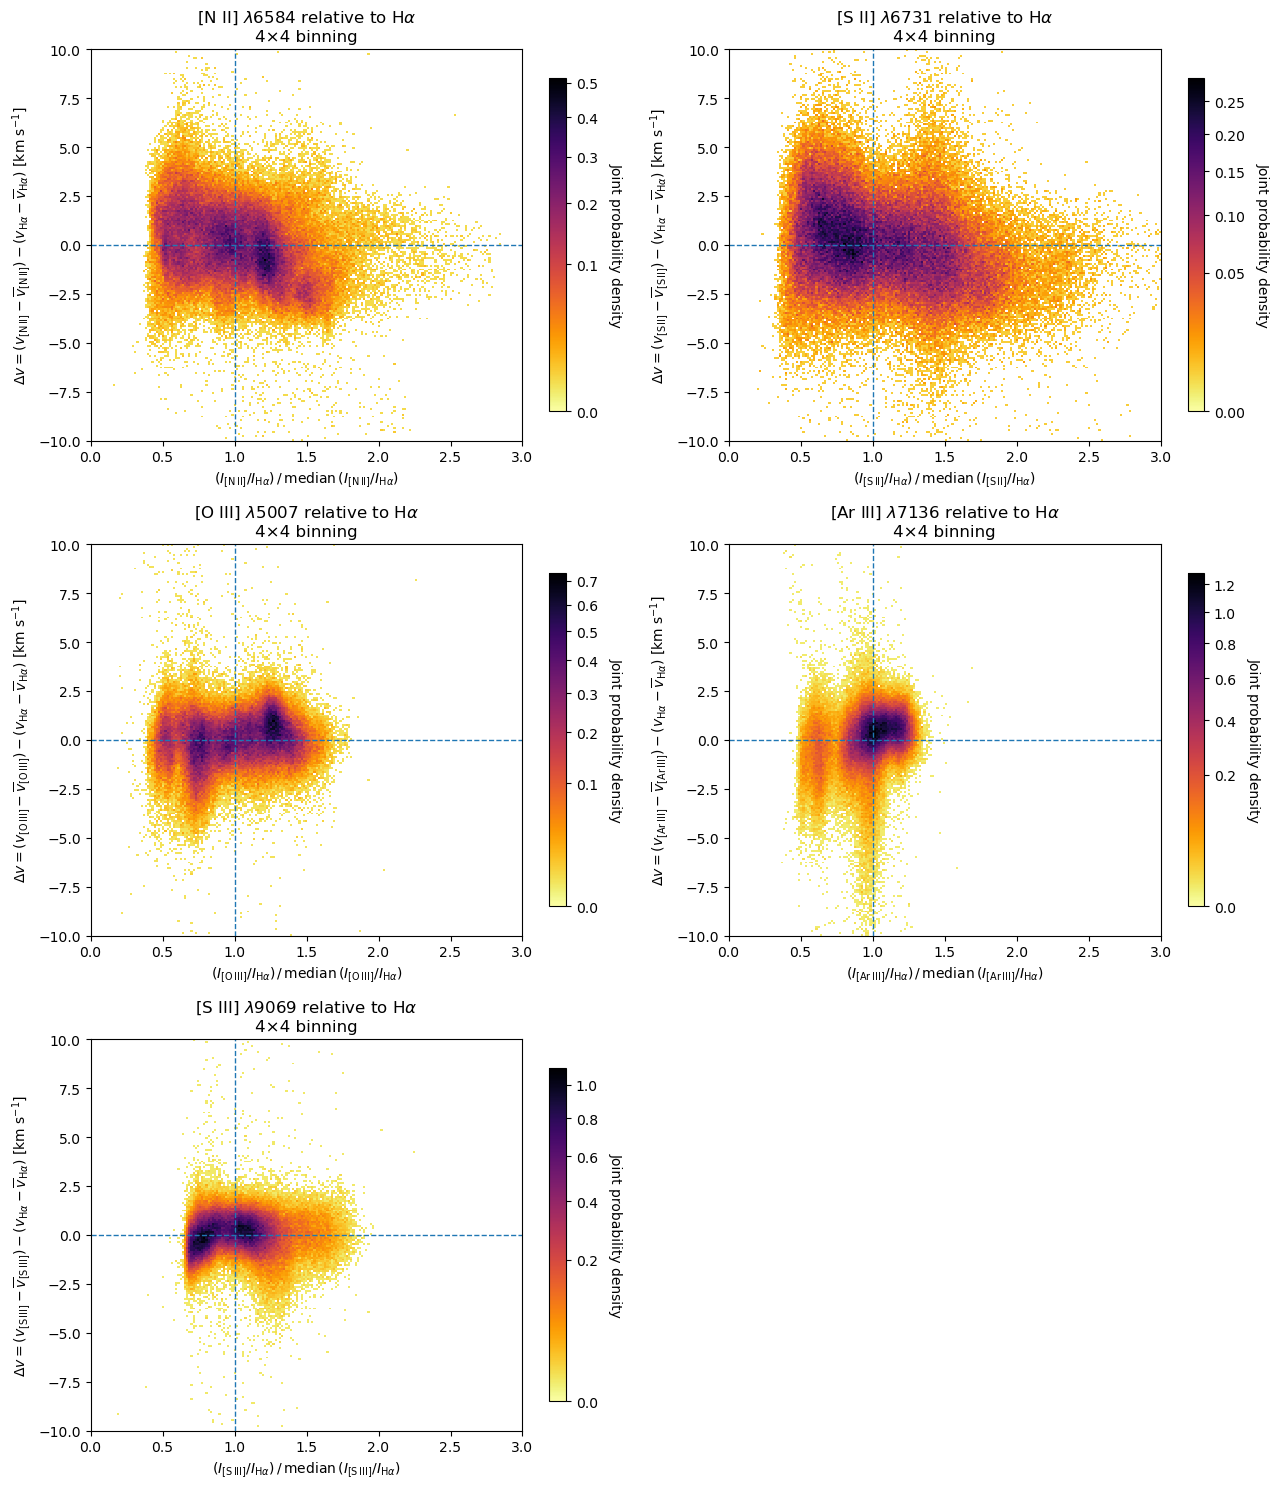

In [61]:
fig, axes = plot_sb_ratio_vs_velocity_difference(
    line_data_binned,
    selected_lines,
    reference_line="Halpha",
    binning=2,
    ratio_min=0,
    ratio_max=3,
    velocity_min=-10,
    velocity_max=10,
    hist_bins=200,
    n_cols=2,
    normalize_ratio=True,
    include_reference=False,
)